# rdkit-dof 示例

这个中文 notebook 覆盖 README 和 Markdown 文档中引用的所有可运行代码示例，并已经执行保存输出。打开后可以直接看到分子渲染结果。

## 公开导入

文档中使用的包级公开导出。

In [1]:
from rdkit_dof import (
    DofDrawSettings,
    MolsToDofGif,
    MolsToDofSvgAnimation,
    MolsToGridDofImage,
    MolToDofImage,
    dofconfig,
)

print(
    DofDrawSettings.__name__,
    MolToDofImage.__name__,
    MolsToGridDofImage.__name__,
    MolsToDofGif.__name__,
    MolsToDofSvgAnimation.__name__,
)

DofDrawSettings MolToDofImage MolsToGridDofImage MolsToDofGif MolsToDofSvgAnimation


## 初始化

导入依赖、定义分子构造 helper，并创建用于文件保存示例的临时输出目录。

In [2]:
import tempfile
from pathlib import Path

from IPython.display import SVG, display
from IPython.display import Image as IPythonImage
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdDistGeom import EmbedMolecule
from rdkit.Chem.rdForceFieldHelpers import MMFFOptimizeMolecule
from rdkit.Geometry import Point2D

work_dir = Path(tempfile.mkdtemp(prefix="rdkit_dof_examples_"))
print(f"临时输出目录: {work_dir}")


def make_3d_mol(smiles: str, seed: int = 42):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    EmbedMolecule(mol, randomSeed=seed)
    MMFFOptimizeMolecule(mol)
    return mol


# Start from known global defaults for reproducible examples.
dofconfig.use_style("default")
dofconfig.fog_color = (0.95, 0.95, 0.95)
dofconfig.min_alpha = 0.4
dofconfig.default_size = (800, 800)

临时输出目录: /tmp/rdkit_dof_examples_qnnrte2_


## README 快速开始

创建乙醇 3D 构象，切换样式，渲染并直接保存 SVG。

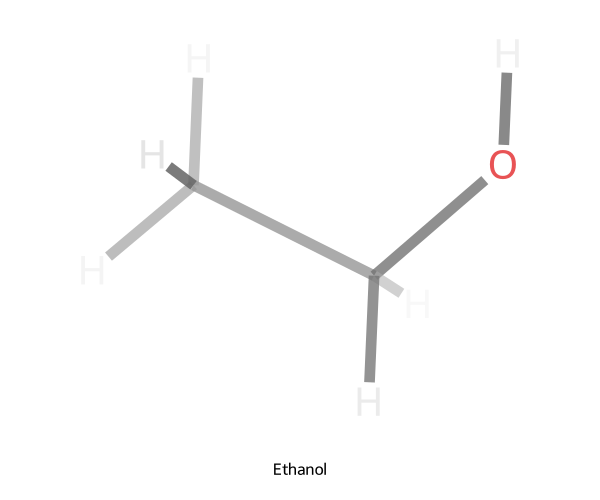

已保存: True -> /tmp/rdkit_dof_examples_qnnrte2_/ethanol.svg


In [3]:
mol = Chem.MolFromSmiles("CCO")
mol = Chem.AddHs(mol)
EmbedMolecule(mol, randomSeed=42)
MMFFOptimizeMolecule(mol)

dofconfig.use_style("nature")

ethanol_svg = work_dir / "ethanol.svg"
display(
    MolToDofImage(
        mol,
        size=(600, 500),
        legend="Ethanol",
        filename=str(ethanol_svg),
    )
)
print(f"已保存: {ethanol_svg.exists()} -> {ethanol_svg}")

## 单分子绘图

3D 构象会为 DOF 效果提供真实深度信息。

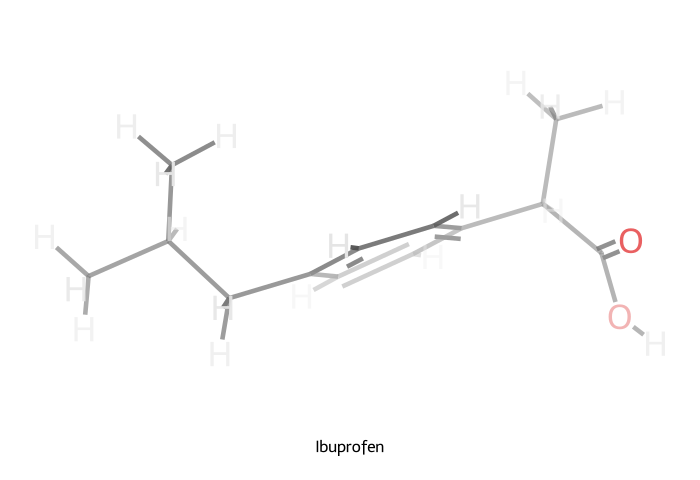

In [4]:
ibuprofen = make_3d_mol("CC(C)CC1=CC=C(C=C1)C(C)C(=O)O")
display(
    MolToDofImage(
        ibuprofen,
        size=(700, 480),
        legend="Ibuprofen",
    )
)

## 没有 3D 构象的分子

如果没有构象，会自动计算 2D 坐标；此时景深变化较平。

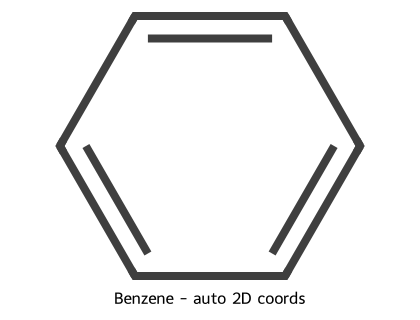

In [5]:
benzene_2d = Chem.MolFromSmiles("c1ccccc1")
display(
    MolToDofImage(
        benzene_2d,
        size=(420, 320),
        legend="Benzene - auto 2D coords",
    )
)

## 输出模式

可以返回 SVG 文本、PNG bytes、Pillow 图像，也可以直接保存文件。

SVG 文本长度: 3,950 characters
PNG 字节长度: 19,088 bytes
PNG 文件已保存: True -> /tmp/rdkit_dof_examples_qnnrte2_/ethanol.png


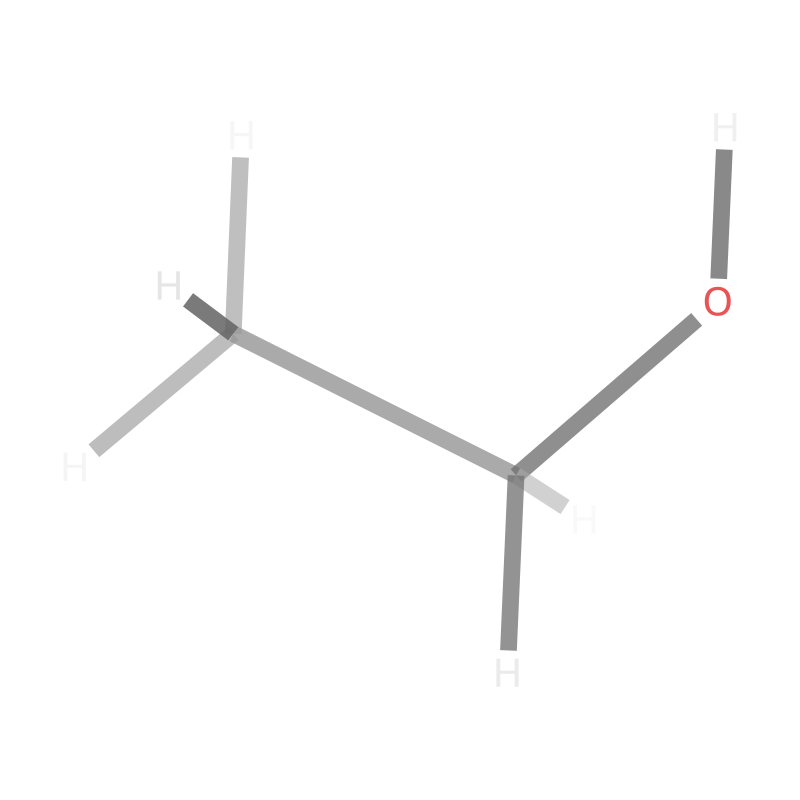

In [6]:
svg_text = MolToDofImage(mol, return_image=False)
png_bytes = MolToDofImage(mol, use_svg=False, return_image=False)
png_image = MolToDofImage(mol, use_svg=False, return_image=True)
png_file = work_dir / "ethanol.png"
MolToDofImage(mol, use_svg=False, filename=str(png_file))

print(f"SVG 文本长度: {len(svg_text):,} characters")
print(f"PNG 字节长度: {len(png_bytes):,} bytes")
print(f"PNG 文件已保存: {png_file.exists()} -> {png_file}")
display(png_image)

## 高亮

通过原子和键索引进行高亮，并指定 RGBA 颜色。被高亮的原子和键会以指定 RGB 颜色完全不透明显示，不参与景深淡化。

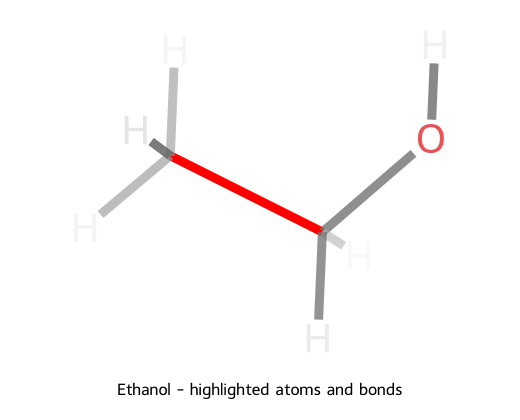

In [7]:
display(
    MolToDofImage(
        mol,
        size=(520, 420),
        legend="Ethanol - highlighted atoms and bonds",
        highlightAtoms=[0, 1],
        highlightBonds=[0],
        highlightColor=(1.0, 0.0, 0.0, 1.0),
    )
)

## 网格绘图

`None` 会渲染为空白单元格；空列表会返回空白图像。

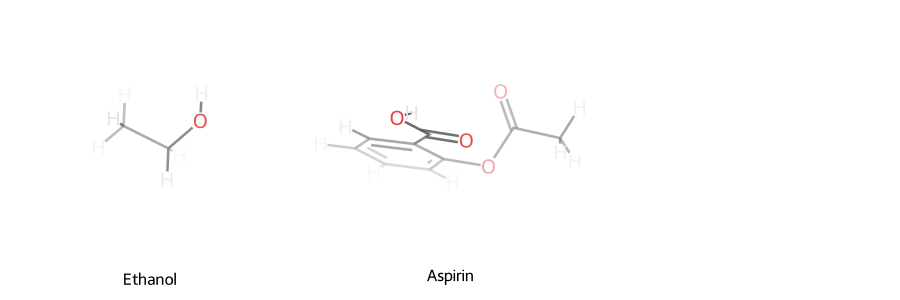

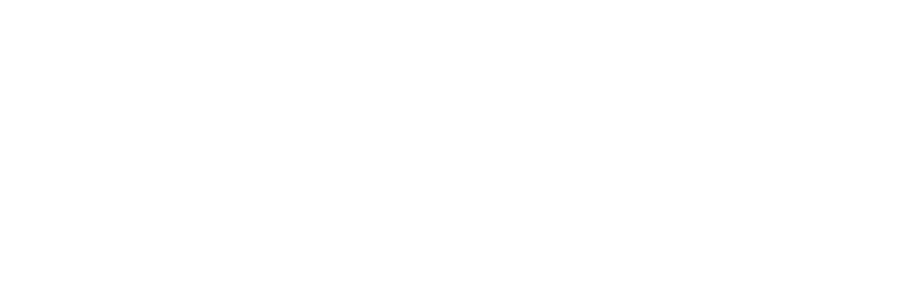

In [8]:
aspirin = make_3d_mol("CC(=O)OC1=CC=CC=C1C(=O)O", seed=2)
caffeine = make_3d_mol("Cn1cnc2c1c(=O)n(C)c(=O)n2C", seed=3)
mols = [mol, aspirin, caffeine]
grid_legends = ["Ethanol", "Aspirin", "Empty"]

display(
    MolsToGridDofImage(
        [mol, aspirin, None],
        molsPerRow=3,
        legends=grid_legends,
        filename=str(work_dir / "grid.svg"),
    )
)

display(MolsToGridDofImage([], use_svg=False, return_image=True))

## 动图绘制

使用 `MolsToDofGif` 生成位图 GIF 动图，使用 `MolsToDofSvgAnimation` 生成矢量 SVG 动画。两个函数都接收一组 RDKit 分子对象，每个分子对应一帧，也可以传入逐帧标题和持续时间。

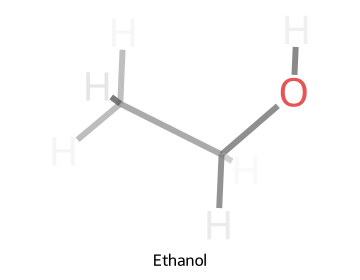

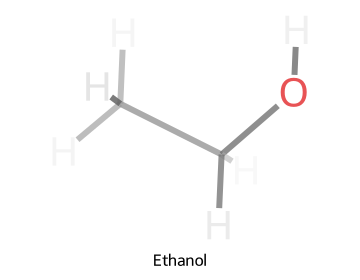

GIF 动图已保存到: /tmp/rdkit_dof_examples_qnnrte2_/molecules.gif
SVG 动画已保存到: /tmp/rdkit_dof_examples_qnnrte2_/molecules.svg


In [9]:
animation_legends = ["Ethanol", "Aspirin", "Caffeine"]
gif_file = work_dir / "molecules.gif"
svg_file = work_dir / "molecules.svg"

# GIF 动图：先保存文件，再用 IPythonImage 显示，让 notebook 嵌入 image/gif，
# 避免把动画 PIL 对象当成静态 PNG 处理。
MolsToDofGif(
    mols,
    size=(360, 280),
    legends=animation_legends,
    duration=[600, 700, 800],
    return_image=False,
    filename=str(gif_file),
)
display(IPythonImage(filename=str(gif_file)))

# SVG 动画：保留矢量绘图效果；当前端/浏览器支持 SVG SMIL 动画时可内联播放。
svg_animation = MolsToDofSvgAnimation(
    mols,
    size=(360, 280),
    legends=animation_legends,
    duration=[600, 700, 800],
    filename=str(svg_file),
)
display(svg_animation)

print(f"GIF 动图已保存到: {gif_file}")
print(f"SVG 动画已保存到: {svg_file}")

## 逐分子网格高亮

`highlightAtomLists` 和 `highlightBondLists` 与 `mols` 序列一一对应。

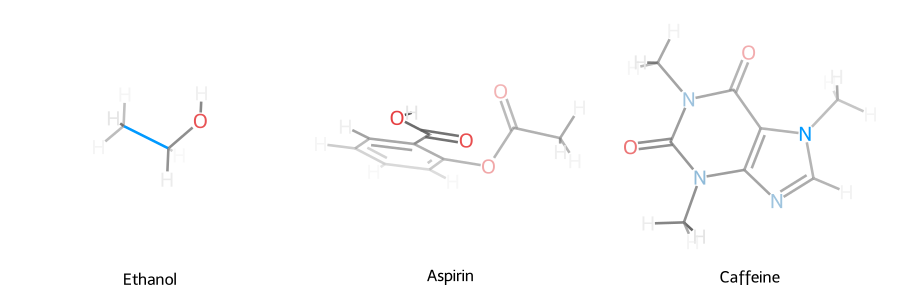

In [10]:
highlight_legends = ["Ethanol", "Aspirin", "Caffeine"]
display(
    MolsToGridDofImage(
        mols,
        molsPerRow=3,
        legends=highlight_legends,
        highlightAtomLists=[[0], [], [1, 2]],
        highlightBondLists=[[0], [], []],
        highlightColor=(0.0, 0.6, 1.0, 1.0),
    )
)

## 全局配置

使用全局 `dofconfig` 设置进程级默认值。

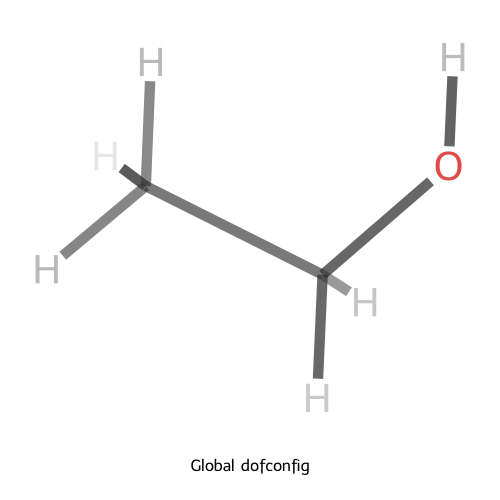

In [11]:
dofconfig.use_style("nature")
dofconfig.fog_color = (0.1, 0.1, 0.1)
dofconfig.min_alpha = 0.3
dofconfig.default_size = (500, 500)
dofconfig.atom_colors[8] = (1.0, 0.2, 0.2)

display(MolToDofImage(mol, legend="Global dofconfig"))

## 局部配置

当某一张图需要区别于全局默认值时，使用 `DofDrawSettings`。

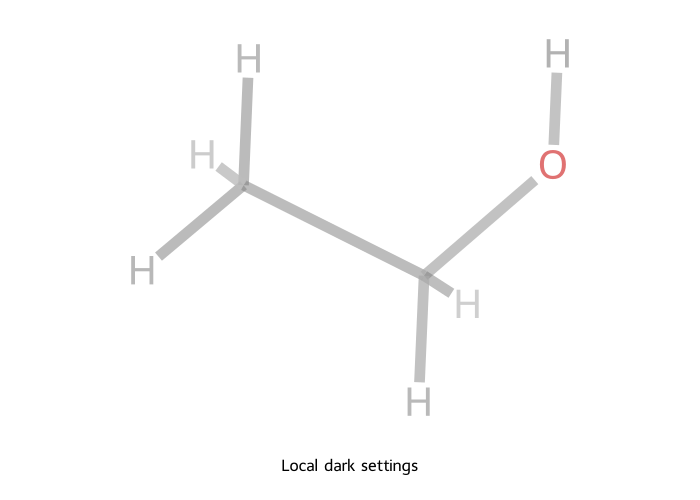

In [12]:
settings = DofDrawSettings(
    preset_style="dark",
    min_alpha=0.25,
    default_size=(700, 500),
)

display(
    MolToDofImage(
        mol,
        settings=settings,
        legend="Local dark settings",
    )
)

## 环境文件配置

同样的配置字段也可以从 `.env` 风格文件加载。

DofDrawSettings(preset_style='dark', fog_color=(0.1, 0.1, 0.1), min_alpha=0.2, default_size=(600, 500), enable_ipython=False, atom_colors={1: (0.8, 0.8, 0.8), 6: (0.9, 0.9, 0.9), 7: (0.3, 0.6, 1.0), 8: (1.0, 0.2, 0.2), 9: (0.2, 1.0, 1.0), 15: (1.0, 0.7, 0.2), 16: (1.0, 1.0, 0.4)})


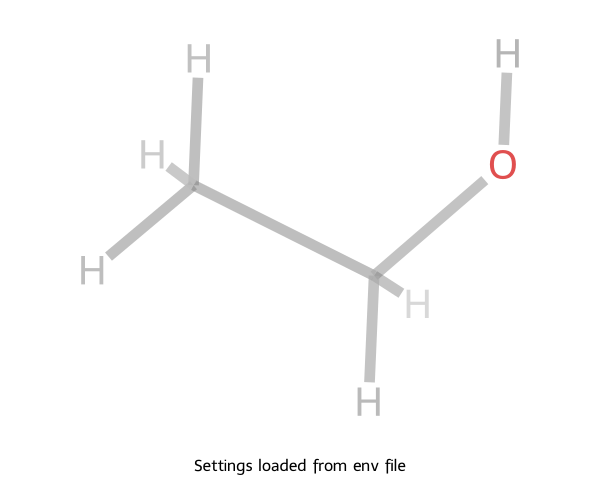

In [13]:
env_file = work_dir / "rdkit_dof.env"
env_lines = [
    "RDKIT_DOF_PRESET_STYLE=dark",
    "RDKIT_DOF_FOG_COLOR=[0.1, 0.1, 0.1]",
    "RDKIT_DOF_MIN_ALPHA=0.2",
    "RDKIT_DOF_DEFAULT_SIZE=[600, 500]",
    "RDKIT_DOF_ENABLE_IPYTHON=false",
    'RDKIT_DOF_ATOM_COLORS={"8": [1.0, 0.2, 0.2]}',
]
env_file.write_text("\n".join(env_lines) + "\n", encoding="utf-8")

env_settings = DofDrawSettings(env_file=env_file)
print(env_settings)
display(
    MolToDofImage(
        mol,
        settings=env_settings,
        legend="Settings loaded from env file",
    )
)

## 自定义 RDKit 绘制

`return_drawer=True` 会在 `FinishDrawing()` 前返回底层 RDKit drawer。

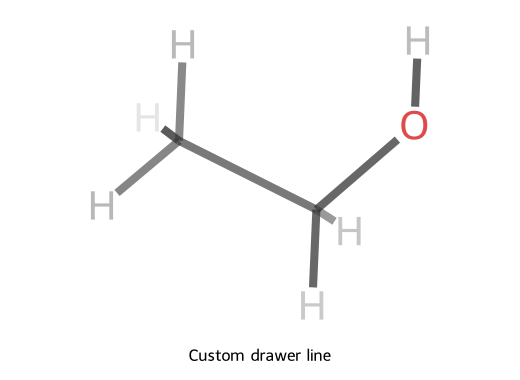

In [14]:
drawer = MolToDofImage(
    mol,
    size=(520, 380),
    legend="Custom drawer line",
    return_drawer=True,
)
drawer.SetColour((1.0, 0.0, 0.0))
drawer.DrawLine(Point2D(30, 30), Point2D(180, 30))
drawer.FinishDrawing()
custom_svg = drawer.GetDrawingText()
display(SVG(custom_svg))

## RDKit 绘图选项和 `**kwargs`

可以通过关键字参数传入 RDKit 绘图选项。`IPythonConsole.drawOptions` 中的选项会先被复制，然后再应用显式关键字参数。

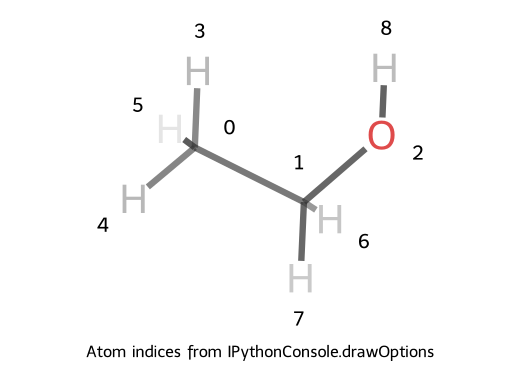

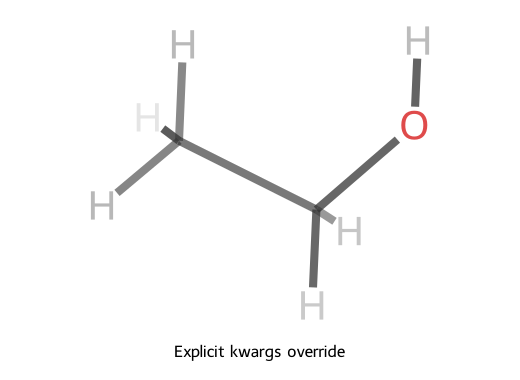

In [15]:
IPythonConsole.drawOptions.addAtomIndices = True
display(
    MolToDofImage(
        mol,
        size=(520, 380),
        legend="Atom indices from IPythonConsole.drawOptions",
    )
)

display(
    MolToDofImage(
        mol,
        size=(520, 380),
        legend="Explicit kwargs override",
        addAtomIndices=False,
    )
)
IPythonConsole.drawOptions.addAtomIndices = False

## Jupyter/IPython 集成

开关 notebook 中 RDKit `Mol` 和 `RWMol` 对象的 DOF 自动渲染。

In [16]:
dofconfig.enable_ipython_integration(True)
print("已启用 notebook 集成")
dofconfig.enable_ipython_integration(False)
print("已关闭 notebook 集成")

已启用 notebook 集成
已关闭 notebook 集成


## 重新生成展示图

在仓库根目录运行：

```bash
python scripts/_generate_comparison_images.py
```